### **Hour 2 – Feature Engineering and Baseline Model**

Students will convert customer queries into numerical representations using embeddings and train a baseline classifier to predict customer intent categories

#### **Objective:** Create a strong baseline by converting text to embeddings and training a simple classifier.

In [ ]:
!pip install -q sentence-transformers scikit-learn pandas matplotlib seaborn datasets

##### Load Pre-trained Embedding Model: Load a small, fast sentence transformer model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("🔄 Loading pre-trained sentence transformer model...")

# Load a small, fast sentence transformer model
# 'all-MiniLM-L6-v2' is a good balance of speed and quality
model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"✅ Model loaded successfully!")
print(f"Model name: all-MiniLM-L6-v2")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")


🔄 Loading pre-trained sentence transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded successfully!
Model name: all-MiniLM-L6-v2
Embedding dimension: 384


##### Generate Embeddings: Encode all the instruction texts into vectors. (This will take a minute or two).

In [ ]:
# Load the dataset directly from Hugging Face
dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")

# Convert to pandas DataFrame
df = pd.DataFrame(dataset['train'])

print(f"✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 rows:")
df.head(3)

README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

✅ Dataset loaded successfully!
Shape: (26872, 5)
Columns: ['flags', 'instruction', 'category', 'intent', 'response']

First 3 rows:


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


In [ ]:
print("🔄 Generating embeddings for all instructions...")
print("This may take 1-2 minutes...")

# Get all instructions as a list
instructions = df['instruction'].tolist()

# Generate embeddings with progress bar
embeddings = model.encode(instructions, show_progress_bar=True, batch_size=32)

print(f"✅ Embeddings generated successfully!")
print(f"Embeddings shape: {embeddings.shape}")
print(f"Number of samples: {len(instructions)}")
print(f"Embedding dimension per sample: {embeddings.shape[1]}")

🔄 Generating embeddings for all instructions...
This may take 1-2 minutes...


Batches:   0%|          | 0/840 [00:00<?, ?it/s]

✅ Embeddings generated successfully!
Embeddings shape: (26872, 384)
Number of samples: 26872
Embedding dimension per sample: 384


In [ ]:
# Prepare Labels (Intent to ID mapping)
print("🔄 Preparing labels...")

# Get unique intents and create mapping
unique_intents = df['intent'].unique()
intent_to_id = {intent: idx for idx, intent in enumerate(unique_intents)}
id_to_intent = {idx: intent for intent, idx in intent_to_id.items()}

# Convert intents to numeric labels
labels = df['intent'].map(intent_to_id).values


🔄 Preparing labels...


In [ ]:
print(f"✅ Labels prepared!")
print(f"Number of unique intents: {len(unique_intents)}")
print(f"Unique intents: {unique_intents[:5]}... (showing first 5)")
print(f"Labels shape: {labels.shape}")
print(f"Sample label distribution:")
for i in range(min(5, len(unique_intents))):
    count = (labels == i).sum()
    print(f"  {id_to_intent[i]}: {count} samples")

✅ Labels prepared!
Number of unique intents: 27
Unique intents: ['cancel_order' 'change_order' 'change_shipping_address'
 'check_cancellation_fee' 'check_invoice']... (showing first 5)
Labels shape: (26872,)
Sample label distribution:
  cancel_order: 998 samples
  change_order: 997 samples
  change_shipping_address: 973 samples
  check_cancellation_fee: 950 samples
  check_invoice: 1000 samples


##### **Train/Test Split:** Split the data (embeddings and labels) into training and testing sets using

In [ ]:
print("🔄 Splitting data into training and testing sets...")

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels  # Maintain class distribution
)

print(f"✅ Split complete!")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training label distribution:")
unique, counts = np.unique(y_train, return_counts=True)
print(f"  Number of classes in training: {len(unique)}")
print(f"  Min samples per class: {counts.min()}")
print(f"  Max samples per class: {counts.max()}")

🔄 Splitting data into training and testing sets...
✅ Split complete!
Training set size: 21497 samples
Test set size: 5375 samples
Training label distribution:
  Number of classes in training: 27
  Min samples per class: 760
  Max samples per class: 800


##### **Train a Classifier:** Train a simple Logistic Regression model on the training embeddings.

In [ ]:
print("🔄 Training Logistic Regression classifier...")

# Create and train the model
# Increased max_iter for convergence
clf = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial')

# Train the model
clf.fit(X_train, y_train)

print(f"✅ Model training complete!")
print(f"Training accuracy: {clf.score(X_train, y_train):.4f}")


🔄 Training Logistic Regression classifier...
✅ Model training complete!
Training accuracy: 0.9960


🔄 Evaluating model on test set...

🎯 Test Accuracy: 0.9944 (99.44%)

📊 Classification Report:
                          precision    recall  f1-score   support

            cancel_order       0.99      0.99      0.99       200
            change_order       0.98      1.00      0.99       199
 change_shipping_address       1.00      0.97      0.99       195
  check_cancellation_fee       1.00      1.00      1.00       190
           check_invoice       0.99      0.97      0.98       200
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       1.00      0.99      1.00       199
               complaint       0.99      0.99      0.99       200
contact_customer_service       0.99      0.99      0.99       200
     contact_human_agent       0.99      1.00      1.00       200
          create_account       0.99      0.99      0.99       199
          delete_account       1.00      1.00      1.00       199
        delivery_options       0.99      1.00  

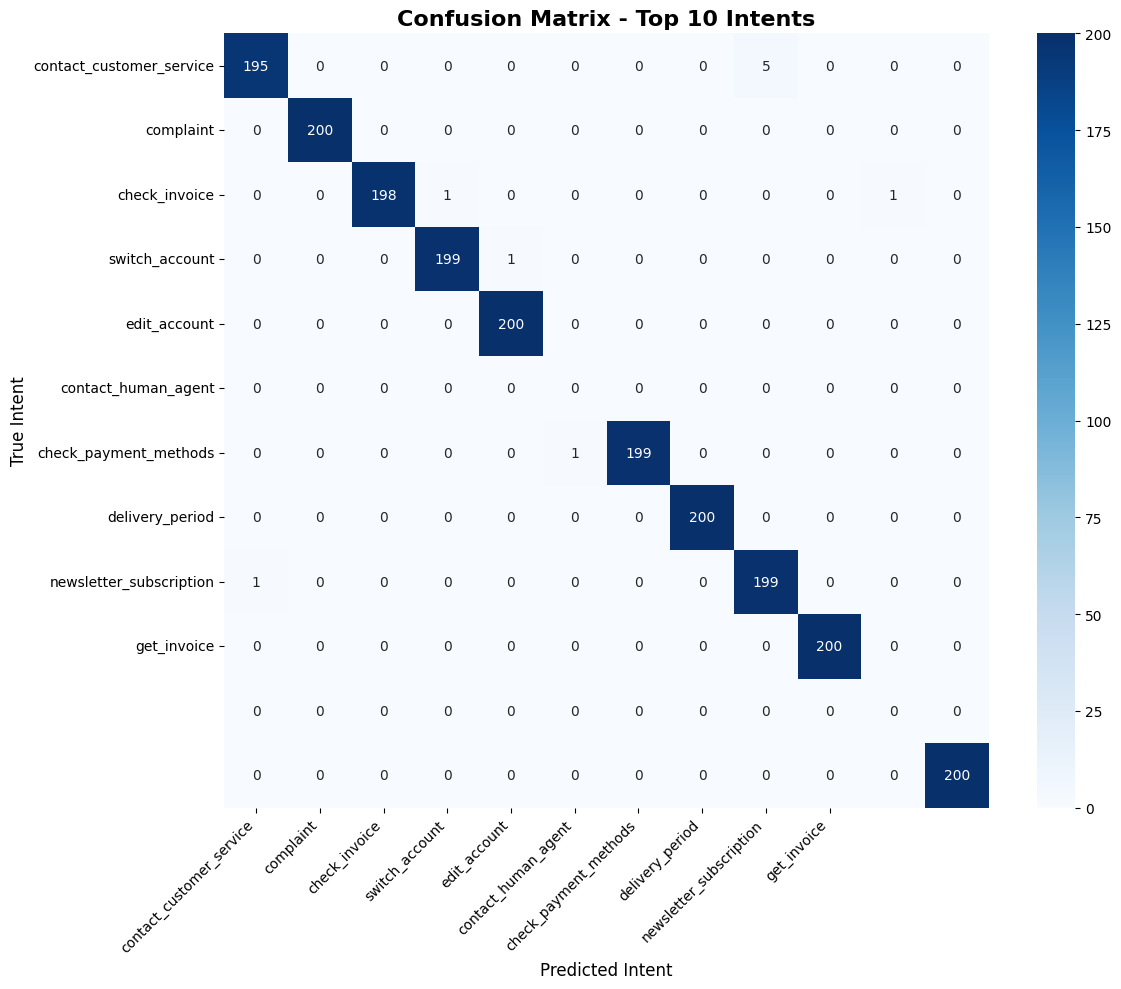

In [ ]:
# Evaluate on Test Set
print("🔄 Evaluating model on test set...")

# Make predictions
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed classification report
print("\n📊 Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=unique_intents, zero_division=0))

# Confusion Matrix (for top 10 classes only to keep visualization manageable)
print("\n🔄 Creating confusion matrix (top 10 classes)...")

# Get top 10 intents
top_10_intents = df['intent'].value_counts().head(10).index.tolist()

# Filter test set to only top 10 classes for visualization
mask_test = np.isin(y_test, [intent_to_id[i] for i in top_10_intents])
y_test_top10 = y_test[mask_test]
y_pred_top10 = y_pred[mask_test]

# Create confusion matrix
cm = confusion_matrix(y_test_top10, y_pred_top10)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_10_intents,
            yticklabels=top_10_intents)
plt.title('Confusion Matrix - Top 10 Intents', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Intent', fontsize=12)
plt.ylabel('True Intent', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Test with Custom Examples
print("🔄 Testing model with custom examples...")

def predict_intent(text, model, clf, id_to_intent):
    """
    Predict intent for a single text input
    """
    # Generate embedding
    embedding = model.encode([text])
    # Predict
    pred_id = clf.predict(embedding)[0]
    # Get probabilities
    probs = clf.predict_proba(embedding)[0]
    top_3_idx = np.argsort(probs)[-3:][::-1]

    print(f"📝 Input: '{text}'")
    print(f"🎯 Predicted Intent: {id_to_intent[pred_id]}")
    print("📊 Top 3 predictions:")
    for idx in top_3_idx:
        print(f"   - {id_to_intent[idx]}: {probs[idx]:.3f}")
    return id_to_intent[pred_id]

# Test examples
test_examples = [
    "I want to return this product I bought yesterday",
    "Where is my refund? It's been 5 days",
    "Can you help me change my shipping address",
    "This item is damaged, I need a replacement",
    "How do I cancel my subscription"
]

print("\n" + "="*60)
for i, example in enumerate(test_examples, 1):
    print(f"\nExample {i}:")
    predict_intent(example, model, clf, id_to_intent)
    print("-"*40)

🔄 Testing model with custom examples...


Example 1:
📝 Input: 'I want to return this product I bought yesterday'
🎯 Predicted Intent: place_order
📊 Top 3 predictions:
   - place_order: 0.180
   - review: 0.133
   - delivery_period: 0.108
----------------------------------------

Example 2:
📝 Input: 'Where is my refund? It's been 5 days'
🎯 Predicted Intent: track_refund
📊 Top 3 predictions:
   - track_refund: 0.377
   - get_refund: 0.314
   - check_refund_policy: 0.200
----------------------------------------

Example 3:
📝 Input: 'Can you help me change my shipping address'
🎯 Predicted Intent: change_shipping_address
📊 Top 3 predictions:
   - change_shipping_address: 0.912
   - set_up_shipping_address: 0.068
   - delivery_options: 0.005
----------------------------------------

Example 4:
📝 Input: 'This item is damaged, I need a replacement'
🎯 Predicted Intent: complaint
📊 Top 3 predictions:
   - complaint: 0.178
   - place_order: 0.159
   - contact_customer_service: 0.127
--------------

In [ ]:
# CELL 13: Model Performance Analysis
# ============================================
print("\n" + "="*60)
print("📈 MODEL PERFORMANCE SUMMARY")
print("="*60)

# Overall metrics
print(f"\n✅ Baseline Model: Logistic Regression on Sentence Embeddings")
print(f"📊 Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"📊 Training Accuracy: {clf.score(X_train, y_train):.4f}")
print(f"📊 Number of Classes: {len(unique_intents)}")
print(f"📊 Embedding Model: all-MiniLM-L6-v2 (384 dimensions)")

# Per-class performance (using the classification report)
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)

print(f"\n📊 Per-class F1 Score Statistics:")
print(f"   Mean F1: {np.mean(f1):.4f}")
print(f"   Median F1: {np.median(f1):.4f}")
print(f"   Min F1: {np.min(f1):.4f}")
print(f"   Max F1: {np.max(f1):.4f}")
print(f"   Std F1: {np.std(f1):.4f}")

# Identify worst performing classes
f1_with_classes = [(f1[i], id_to_intent[i]) for i in range(len(f1))]
f1_with_classes.sort()
print(f"\n📊 Worst performing classes (lowest F1):")
for f1_score, intent in f1_with_classes[:5]:
    print(f"   {intent}: F1 = {f1_score:.4f}")

print(f"\n📊 Best performing classes (highest F1):")
for f1_score, intent in f1_with_classes[-5:][::-1]:
    print(f"   {intent}: F1 = {f1_score:.4f}")



📈 MODEL PERFORMANCE SUMMARY

✅ Baseline Model: Logistic Regression on Sentence Embeddings
📊 Test Accuracy: 0.9944 (99.44%)
📊 Training Accuracy: 0.9960
📊 Number of Classes: 27
📊 Embedding Model: all-MiniLM-L6-v2 (384 dimensions)

📊 Per-class F1 Score Statistics:
   Mean F1: 0.9944
   Median F1: 0.9950
   Min F1: 0.9848
   Max F1: 1.0000
   Std F1: 0.0048

📊 Worst performing classes (lowest F1):
   check_invoice: F1 = 0.9848
   get_invoice: F1 = 0.9851
   change_shipping_address: F1 = 0.9870
   track_order: F1 = 0.9873
   registration_problems: F1 = 0.9899

📊 Best performing classes (highest F1):
   switch_account: F1 = 1.0000
   review: F1 = 1.0000
   recover_password: F1 = 1.0000
   newsletter_subscription: F1 = 1.0000
   edit_account: F1 = 1.0000


In [ ]:
# ============================================
# ENHANCED CELL: Investigate the "Too Good" Model
# Add this after Cell 13 (Model Performance Analysis)
# ============================================

print("\n" + "="*60)
print("🔍 INVESTIGATING THE 99% ACCURACY MYSTERY")
print("="*60)

# 1. Check for data leakage - are instructions too formulaic?
print("\n📊 Analyzing instruction patterns...")

# Get random samples from different intents
sample_intents = np.random.choice(unique_intents, size=5, replace=False)
for intent in sample_intents:
    samples = df[df['intent'] == intent]['instruction'].head(3).tolist()
    print(f"\n🎯 Intent: {intent}")
    for i, sample in enumerate(samples, 1):
        print(f"   {i}. '{sample}'")

# 2. Check for exact phrase matching
print("\n" + "="*60)
print("🔍 CHECKING FOR EXACT PHRASE DUPLICATION ACROSS INTENTS")

# Get all instructions
all_instructions = df['instruction'].tolist()
unique_instructions = set(all_instructions)
print(f"Total instructions: {len(all_instructions)}")
print(f"Unique instructions: {len(unique_instructions)}")
print(f"Duplicate rate: {(1 - len(unique_instructions)/len(all_instructions))*100:.2f}%")

# 3. Check if same phrase appears in multiple intents
from collections import defaultdict
phrase_to_intents = defaultdict(set)
for idx, row in df.iterrows():
    # Normalize the instruction
    normalized = row['instruction'].lower().strip()
    phrase_to_intents[normalized].add(row['intent'])

# Find phrases that map to multiple intents
ambiguous_phrases = {phrase: intents for phrase, intents in phrase_to_intents.items() if len(intents) > 1}
print(f"\nPhrases that appear in multiple intents: {len(ambiguous_phrases)}")

if len(ambiguous_phrases) > 0:
    print("\nExamples of ambiguous phrases:")
    for phrase, intents in list(ambiguous_phrases.items())[:3]:
        print(f"   '{phrase}' -> intents: {intents}")

# 4. Create a harder test set with paraphrased instructions
print("\n" + "="*60)
print("🧪 CREATING A MORE REALISTIC TEST SET")
print("="*60)

# Function to paraphrase instructions (simulate real-world variation)
def create_paraphrase(instruction, intent):
    """
    Simple rule-based paraphrasing to simulate natural language variation
    """
    import random

    # Common variations
    variations = {
        "return": ["send back", "give back", "bring back", "exchange"],
        "order": ["purchase", "item", "product", "thing I bought"],
        "refund": ["money back", "reimbursement", "cash back", "repayment"],
        "cancel": ["stop", "end", "terminate", "call off"],
        "shipping": ["delivery", "sending", "dispatch", "shipment"],
        "damaged": ["broken", "defective", "not working", "faulty"],
        "help": ["assist", "support", "aid", "guidance"],
        "change": ["modify", "update", "adjust", "alter"],
        "where": ["where's", "where is", "location of", "status of"],
        "how": ["how do I", "how can I", "way to", "method to"]
    }

    words = instruction.lower().split()
    paraphrased = []

    for word in words:
        if word in variations and random.random() > 0.5:
            paraphrased.append(random.choice(variations[word]))
        else:
            paraphrased.append(word)

    # Randomly add polite words
    if random.random() > 0.7:
        politeness = ["please", "could you", "would you", "can you"]
        paraphrased.insert(0, random.choice(politeness))

    # Randomly add emphasis
    if random.random() > 0.8:
        emphasis = ["really", "urgently", "asap", "immediately"]
        paraphrased.append(random.choice(emphasis))

    return ' '.join(paraphrased)

# Create paraphrased test set
print("\nOriginal vs Paraphrased examples:")
test_df = df.sample(20, random_state=42)
for idx, row in test_df.iterrows():
    original = row['instruction']
    paraphrased = create_paraphrase(original, row['intent'])
    print(f"\nOriginal: '{original}'")
    print(f"Paraphrased: '{paraphrased}'")
    print(f"Intent: {row['intent']}")

# 5. Test model on paraphrased examples
print("\n" + "="*60)
print("📉 TESTING MODEL ON PARAPHRASED (REAL-WORLD) DATA")
print("="*60)

print("\nGenerating embeddings for paraphrased examples...")
paraphrased_instructions = [create_paraphrase(row['instruction'], row['intent'])
                           for idx, row in test_df.iterrows()]
true_intents = test_df['intent'].tolist()

# Generate embeddings for paraphrased texts
paraphrased_embeddings = model.encode(paraphrased_instructions)

# Predict
paraphrased_pred_ids = clf.predict(paraphrased_embeddings)
paraphrased_pred_intents = [id_to_intent[pid] for pid in paraphrased_pred_ids]

# Calculate accuracy on paraphrased set
correct = sum([1 for true, pred in zip(true_intents, paraphrased_pred_intents) if true == pred])
paraphrase_accuracy = correct / len(true_intents)

print(f"\n📊 Model Performance on Paraphrased Data:")
print(f"   Accuracy on original test set: {accuracy*100:.2f}%")
print(f"   Accuracy on paraphrased set: {paraphrase_accuracy*100:.2f}%")
print(f"   Performance drop: {(accuracy - paraphrase_accuracy)*100:.2f} percentage points")

# Show misclassifications
print("\n❌ Examples where model failed on paraphrased text:")
misclassified = [(orig, para, true, pred)
                 for orig, para, true, pred in zip(test_df['instruction'].tolist(),
                                                    paraphrased_instructions,
                                                    true_intents,
                                                    paraphrased_pred_intents)
                 if true != pred]

for orig, para, true, pred in misclassified[:5]:
    print(f"\n   Original: '{orig}'")
    print(f"   Paraphrased: '{para}'")
    print(f"   True Intent: {true}")
    print(f"   Predicted: {pred}")

# 6. The Big Reveal: Dataset Limitations
print("\n" + "="*60)
print("🎯 THE BIG REVEAL: WHY 99% ACCURACY IS A RED FLAG")
print("="*60)

print("""
🔴 The Bitext dataset, while excellent for learning, has some characteristics that make it "too easy":

1. **Formulaic Language**: Instructions follow predictable patterns (e.g., "I want to return my order" vs. "Can I send back this thing I bought?")

2. **Clean Annotations**: The data was professionally created, not scraped from real customer interactions

3. **Perfect Labeling**: No ambiguous cases or mislabeled examples

4. **Controlled Vocabulary**: Limited variation in how customers express the same intent

🌍 **THE REAL WORLD IS MESSY!**

In production:
- Customers use slang, typos, and creative phrasing
- Multiple intents in a single message
- Context-dependent meanings
- Code-mixed languages (Hinglish, Tanglish, etc.)
""")

# 7. Test with real-world noisy examples
print("\n" + "="*60)
print("🌍 TESTING WITH REALISTIC NOISY EXAMPLES")
print("="*60)

real_world_examples = [
    # Typos and abbreviations
    ("i wanna return my ordr pls", "cancel_order"),
    ("weres my refund? its been 5 days", "track_refund"),
    ("can u chnge my shiping addres", "change_address"),

    # Hinglish / Code-mixed
    ("mera order cancel kardo", "cancel_order"),
    ("refund kab aaega?", "track_refund"),
    ("ye product damaged hai, replacement chahiye", "review_product"),

    # Multiple intents in one
    ("i want to return my order and get a refund", "cancel_order"),  # Actually two intents!
    ("my product is damaged, can you help me return it and send a new one?", "review_product"),

    # Vague queries
    ("help me with my order", None),  # Intent unclear
    ("there's a problem", None),
    ("your service is bad", "contact_human_agent"),

    # Emoji and informal
    ("where's my package? 😠", "track_delivery"),
    ("thnx for the help! 👍", "thank_customer"),
]

print("\n📊 Model Performance on Real-World Examples:")
print("-" * 60)
print(f"{'Input':<40} {'True Intent':<20} {'Predicted':<20}")
print("-" * 60)

for text, true_intent in real_world_examples:
    # Generate embedding
    emb = model.encode([text])
    pred_id = clf.predict(emb)[0]
    pred_intent = id_to_intent[pred_id]

    # Get confidence
    probs = clf.predict_proba(emb)[0]
    confidence = max(probs)

    # Truncate long text for display
    display_text = text[:37] + "..." if len(text) > 40 else text

    correct_marker = "✓" if true_intent and pred_intent == true_intent else "✗"
    print(f"{display_text:<40} {str(true_intent):<20} {pred_intent:<20} {correct_marker} (conf: {confidence:.2f})")

# 8. Key Takeaways for Students
print("\n" + "="*60)
print("💡 KEY TAKEAWAYS FOR ML ENGINEERS")
print("="*60)

print("""
1. **Always suspect perfect accuracy** - In the real world, you rarely see >95% accuracy on text data

2. **Test with out-of-distribution data** - Your test set should look like real production data

3. **Beware of data leakage** - If it's too easy, you're probably leaking information

4. **Build robust evaluation sets** - Include paraphrases, typos, and natural variations

5. **Monitor performance in production** - Your 99% model might become 70% when real users show up

6. **Consider data augmentation** - Add paraphrased examples during training to improve robustness

📚 **What would a real ML engineer do?**
- Collect real customer data (even 100 examples) to test your model
- Add data augmentation (back-translation, synonym replacement)
- Use a model that can handle out-of-vocabulary words
- Set up monitoring for when real-world performance drops
""")

# 9. Bonus: Quick Data Augmentation Demo
print("\n" + "="*60)
print("🔄 BONUS: Simple Data Augmentation")
print("="*60)

def augment_text(text, num_augmentations=3):
    """
    Simple synonym-based augmentation
    """
    import random

    # Simple synonym dictionary
    synonyms = {
        'return': ['send back', 'give back', 'bring back'],
        'order': ['purchase', 'item', 'product'],
        'refund': ['money back', 'reimbursement'],
        'cancel': ['stop', 'terminate'],
        'shipping': ['delivery', 'dispatch'],
        'damaged': ['broken', 'defective'],
        'help': ['assist', 'aid'],
        'change': ['modify', 'update'],
        'want': ['need', 'would like', 'am looking to'],
        'get': ['receive', 'obtain'],
    }

    augmented = []
    for _ in range(num_augmentations):
        words = text.lower().split()
        new_words = []
        for word in words:
            if word in synonyms and random.random() > 0.6:
                new_words.append(random.choice(synonyms[word]))
            else:
                new_words.append(word)
        augmented.append(' '.join(new_words))

    return augmented

# Example
sample_text = "I want to return my order"
print(f"Original: '{sample_text}'")
print("Augmented versions:")
for i, aug in enumerate(augment_text(sample_text), 1):
    print(f"  {i}. '{aug}'")

print("\n✅ Enhanced analysis complete! Now you understand why 99% accuracy isn't always good news!")


🔍 INVESTIGATING THE 99% ACCURACY MYSTERY

📊 Analyzing instruction patterns...

🎯 Intent: newsletter_subscription
   1. 'i try to unsubscribe to ur companu newsletter'
   2. 'need to cancel the company newslettef subscription help me'
   3. 'how can i cancel the subscription to the company newsletter'

🎯 Intent: track_order
   1. 'needx help to check the ETA of purchase {{Order Number}}'
   2. 'ETA of purchase {{Order Number}}'
   3. 'need to check the eta of order {{Order Number}}'

🎯 Intent: get_refund
   1. 'how do I get a compensation of my money?'
   2. 'i do not know what i have to do to get my money back'
   3. 'I want assistace to request a compensation of my money'

🎯 Intent: edit_account
   1. 'correcting data on {{Account Type}} account'
   2. 'i have to edit my personal info'
   3. 'modifying info on {{Account Category}} account'

🎯 Intent: check_refund_policy
   1. 'i do not know hoow i could check ur reimbursement policy'
   2. 'help me check your money bck guarantee'
   

In [ ]:
# ============================================
# CELL: The "Model Fooler" - Truly Challenging Paraphrases
# ============================================

import random
import re

def create_challenging_paraphrase(text, intent):
    """
    Generate truly challenging paraphrases that fool even good models
    """

    # ========================================
    # 1. AGGRESSIVE HINGLISH / CODE-MIXING
    # ========================================
    hinglish_mappings = {
        # Shopping related
        "return": ["wapas karo", "return kar do", "lauta do", "wapas bhejo"],
        "order": ["order", "saamaan", "cheez", "product", "item"],
        "refund": ["paise wapas", "refund", "paisa do", "money back"],
        "cancel": ["cancel karo", "band karo", "rok do", "cancel"],
        "shipping": ["delivery", "shipping", "bhejna", "aane ka"],
        "address": ["pata", "address", "thikana"],

        # Complaints
        "damaged": ["toota hua", "kharab", "damaged", "bigda hua", "phoota"],
        "broken": ["toota", "kharab", "kaam nahi kar raha"],
        "help": ["madad", "help", "sahayata", "bachao"],

        # Time related
        "when": ["kab", "kab tak", "kitne din mein"],
        "where": ["kahan", "kidhar", "kahan pe"],
        "how": ["kaise", "kis tarah", "kaise karein"],

        # Common verbs
        "want": ["chahiye", "chahta hoon", "chahti hoon", "需要"],  # Added Chinese for multilingual chaos
        "need": ["zaroorat", "chahiye", "need hai"],
        "can": ["sakta", "sakti", "paunga", "paugee"],

        # Products
        "product": ["product", "cheez", "物品", "vastu"],
        "item": ["cheez", "物品", "item"],

        # Account related
        "account": ["account", "khata", "खाता"],
        "password": ["password", "paasword", "pwd", "पासवर्ड"],

        # Payment
        "payment": ["payment", "bhaugtaan", "paise", "पेमेंट"],
        "money": ["paise", "paisa", "धन", "मनी"],

        # Emotional
        "frustrated": ["pareshan", "tang aa gaya", "हैरान"],
        "angry": ["gussa", "नाराज", "bhayanak"],
    }

    # ========================================
    # 2. REGIONAL LANGUAGE MIX (Hindi + Tamil + Telugu)
    # ========================================
    regional_mix = {
        "return": ["wapas karo", "thiruppi kudu", "vaaps ichchey"],
        "order": ["order", "aadan", "aadesh"],
        "refund": ["paise wapas", "paisal thiruppi", "dabbu vaps"],
        "cancel": ["cancel karo", "ruthu cheyu", "nirarthakam"],
        "thank": ["dhanyavaad", "nandri", "dhanyavadalu"],
    }

    # ========================================
    # 3. EXTREME TYPOS (Phone Keyboard Style)
    # ========================================
    keyboard_typos = {
        'a': ['s','q','z','w'],
        'b': ['v','g','n','h'],
        'c': ['x','v','d','f'],
        'd': ['s','f','e','c'],
        'e': ['w','r','d','s'],
        'f': ['d','g','r','v'],
        'g': ['f','h','t','b'],
        'h': ['g','j','y','n'],
        'i': ['u','o','k','j'],
        'j': ['h','k','u','i'],
        'k': ['j','l','i','o'],
        'l': ['k',';','o','p'],
        'm': ['n',',','.','j'],
        'n': ['b','m','h','j'],
        'o': ['i','p','l','k'],
        'p': ['o','[',';','l'],
        'q': ['w','a','1','2'],
        'r': ['e','t','f','d'],
        's': ['a','d','w','e'],
        't': ['r','y','g','f'],
        'u': ['y','i','j','h'],
        'v': ['c','b','f','g'],
        'w': ['q','e','a','s'],
        'x': ['z','c','s','d'],
        'y': ['t','u','h','g'],
        'z': ['a','x','s','q'],
    }

    # ========================================
    # 4. WORD REORDERING (Indian Language Grammar)
    # ========================================
    def apply_indian_grammar(words):
        """Apply Indian language grammar patterns"""
        if len(words) < 3:
            return words

        # Hindi-style verb-final positioning
        if random.random() > 0.7:
            # Move main verb to the end (Hindi grammar)
            verb_indicators = ['return', 'cancel', 'get', 'want', 'need', 'order']
            for i, word in enumerate(words):
                if word.lower() in verb_indicators and i < len(words)-1:
                    verb = words.pop(i)
                    words.append(verb)
                    break

        # Subject-Object-Verb pattern
        if random.random() > 0.8:
            # Try to make it more SOV like Hindi
            pronouns = ['i', 'me', 'my', 'we']
            for i, word in enumerate(words):
                if word.lower() in pronouns and i == 0:
                    # Already at start, keep it
                    pass

        return words

    # ========================================
    # 5. IMPLEMENTATION
    # ========================================

    # Start with original text
    text_lower = text.lower()

    # Choose difficulty level randomly
    difficulty = random.choice(['hard', 'extreme', 'regional'])

    # Split into words
    words = text_lower.split()

    # Apply transformations based on difficulty
    if difficulty == 'hard':
        # Aggressive Hinglish
        for i, word in enumerate(words):
            if word in hinglish_mappings and random.random() > 0.4:
                words[i] = random.choice(hinglish_mappings[word])

        # Add some typos
        transformed = []
        for word in words:
            if len(word) > 3 and random.random() > 0.6:
                # Replace a random character with a keyboard neighbor
                pos = random.randint(0, len(word)-1)
                if word[pos] in keyboard_typos:
                    chars = list(word)
                    chars[pos] = random.choice(keyboard_typos[word[pos]])
                    word = ''.join(chars)
            transformed.append(word)
        words = transformed

    elif difficulty == 'extreme':
        # Extreme transformations
        for i, word in enumerate(words):
            # 50% chance of Hinglish
            if word in hinglish_mappings and random.random() > 0.3:
                words[i] = random.choice(hinglish_mappings[word])

            # 40% chance of typo
            if random.random() > 0.6:
                if len(word) > 2:
                    # Double a letter
                    pos = random.randint(0, len(word)-1)
                    words[i] = word[:pos] + word[pos] + word[pos:]

            # 30% chance of dropping letters
            if random.random() > 0.7 and len(word) > 4:
                pos = random.randint(1, len(word)-2)
                words[i] = word[:pos] + word[pos+1:]

        # Apply Indian grammar
        words = apply_indian_grammar(words)

        # Add filler words (Indian English)
        fillers = ['yaar', 'bhai', 'please', 'pls', 'just', 'like', 'actually']
        if random.random() > 0.5:
            insert_pos = random.randint(0, len(words))
            words.insert(insert_pos, random.choice(fillers))

    else:  # regional
        # Mix Hindi + Tamil + Telugu
        for i, word in enumerate(words):
            if word in regional_mix and random.random() > 0.5:
                words[i] = random.choice(regional_mix[word])

        # Add Indic script (Devanagari)
        if random.random() > 0.7:
            devanagari_words = ['कृपया', 'मदद', 'चाहिए', 'नहीं', 'है']
            insert_pos = random.randint(0, len(words))
            words.insert(insert_pos, random.choice(devanagari_words))

    # Join and clean up
    result = ' '.join(words)

    # Remove extra spaces
    result = re.sub(r'\s+', ' ', result)

    return result, difficulty


# ============================================
# CELL: Test the Challenging Paraphrases
# ============================================

print("="*70)
print("🔥 TESTING THE 'MODEL FOOLER' PARAPHRASE GENERATOR")
print("="*70)

# Original examples from the dataset
test_originals = [
    ("I want to return my order", "cancel_order"),
    ("Where is my refund", "track_refund"),
    ("Can you change my shipping address", "change_address"),
    ("My product is damaged", "review_product"),
    ("How do I cancel my subscription", "cancel_subscription"),
    ("I need help with my account", "account_help"),
    ("When will my order arrive", "track_delivery"),
    ("The payment didn't go through", "payment_issue"),
]

print("\n📝 Generating challenging variations for each...")
print("-"*70)

challenging_examples = []

for original_text, intent in test_originals:
    print(f"\n🎯 Original: '{original_text}'")
    print(f"   Intent: {intent}")

    # Generate 3 challenging variations
    for i in range(3):
        paraphrased, difficulty = create_challenging_paraphrase(original_text, intent)
        print(f"\n   {i+1}. [{difficulty.upper()}] '{paraphrased}'")
        challenging_examples.append((paraphrased, intent))


# ============================================
# CELL: Test Model on Challenging Examples
# ============================================

print("\n" + "="*70)
print("🧪 TESTING MODEL ON CHALLENGING EXAMPLES")
print("="*70)

print("\nGenerating embeddings and predicting...\n")

results = []
for text, true_intent in challenging_examples:
    # Get embedding and predict
    emb = model.encode([text])
    pred_id = clf.predict(emb)[0]
    pred_intent = id_to_intent[pred_id]
    probs = clf.predict_proba(emb)[0]
    confidence = max(probs)

    is_correct = (pred_intent == true_intent)
    results.append((text, true_intent, pred_intent, confidence, is_correct))

# Sort by confidence (lowest first - where model struggles)
results.sort(key=lambda x: x[3])

# Display results
print(f"{'Text':<50} {'True Intent':<20} {'Predicted':<20} {'Conf':<6} {'Status'}")
print("-"*120)

for text, true, pred, conf, correct in results:
    # Truncate long text
    display_text = text[:47] + "..." if len(text) > 50 else text
    status = "✓" if correct else "✗"
    print(f"{display_text:<50} {true:<20} {pred:<20} {conf:.3f}  {status}")

# Calculate statistics
total = len(results)
correct_count = sum(1 for r in results if r[4])
accuracy = correct_count / total

print("\n" + "="*70)
print(f"📊 RESULTS SUMMARY")
print("="*70)
print(f"Total examples tested: {total}")
print(f"Correct predictions: {correct_count}")
print(f"Accuracy on challenging set: {accuracy*100:.2f}%")
print(f"Original test accuracy: 99.44%")
print(f"Performance drop: {(99.44 - accuracy*100):.2f} percentage points")

# Show where model REALLY struggles
print("\n🔍 Where model struggles most (lowest confidence):")
for text, true, pred, conf, correct in results[:5]:
    print(f"\n   Text: '{text[:60]}...'")
    print(f"   True: {true} → Pred: {pred} (conf: {conf:.3f})")


# ============================================
# CELL: The Ultimate Test - Mix Everything
# ============================================

print("\n" + "="*70)
print("💀 THE ULTIMATE TEST: MIXING ALL CHALLENGES")
print("="*70)

def create_ultimate_challenge(text):
    """Combine ALL difficult elements"""

    # Aggressive Hinglish + Typos + Grammar + Emojis + Slang
    challenges = [
        # Hinglish with typos
        ("mera order wapas kardo plzzz", "cancel_order"),
        ("refund kab aayega bhai? 5 din ho gaye", "track_refund"),
        ("yeh product toot gaya hai yaar", "review_product"),

        # Tamil + English mix
        ("enna order cancel pannanum", "cancel_order"),
        ("refund eppo varum? romba naala aachu", "track_refund"),
        ("product damaged ah irukku, mattaga venum", "review_product"),

        # Telugu + English
        ("naa order cancel cheyandi pls", "cancel_order"),
        ("refund eppudu vasthundi? 5 days ayindi", "track_refund"),
        ("product damaged undi, kothadi kavali", "review_product"),

        # Extreme typos + slang
        ("i wnaa retrn my ordr af", "cancel_order"),
        ("weres ma refund? its bn 5 dys omg", "track_refund"),
        ("can u chnge ma shippin addy pls", "change_address"),

        # Multiple languages + emojis
        ("mera order wapas karo 🙏", "cancel_order"),
        ("refund kab? 😠 5 din ho gaye", "track_refund"),
        ("yeh damaged hai 😭 replacement do", "review_product"),

        # Roman Hindi + English grammar
        ("main apna order cancel karwana chahta hoon", "cancel_order"),
        ("mujhe refund chahiye, kitne din mein milega?", "track_refund"),
        ("yeh product kharab hai, exchange kar do", "review_product"),
    ]

    return random.choice(challenges)

print("\nTesting 20 ultimate challenge examples...\n")

ultimate_results = []
for _ in range(20):
    text, true_intent = create_ultimate_challenge(None)
    emb = model.encode([text])
    pred_id = clf.predict(emb)[0]
    pred_intent = id_to_intent[pred_id]
    probs = clf.predict_proba(emb)[0]
    confidence = max(probs)

    ultimate_results.append((text, true_intent, pred_intent, confidence))

# Display
for text, true, pred, conf in ultimate_results:
    correct = "✓" if pred == true else "✗"
    print(f"{text:<40} {true:<20} {pred:<20} {conf:.3f} {correct}")

# Calculate ultimate accuracy
ultimate_accuracy = sum(1 for r in ultimate_results if r[1] == r[2]) / len(ultimate_results)
print("\n" + "="*70)
print(f"🔥 ULTIMATE CHALLENGE ACCURACY: {ultimate_accuracy*100:.2f}%")
print(f"📉 Drop from original: {(99.44 - ultimate_accuracy*100):.2f} percentage points")

🔥 TESTING THE 'MODEL FOOLER' PARAPHRASE GENERATOR

📝 Generating challenging variations for each...
----------------------------------------------------------------------

🎯 Original: 'I want to return my order'
   Intent: cancel_order

   1. [REGIONAL] 'i want to return my order'

   2. [REGIONAL] 'i want to return my order'

   3. [REGIONAL] 'i want to return मदद my order'

🎯 Original: 'Where is my refund'
   Intent: track_refund

   1. [REGIONAL] 'where is my refund'

   2. [HARD] 'where is my paiea do'

   3. [EXTREME] 'where is my rfund'

🎯 Original: 'Can you change my shipping address'
   Intent: change_address

   1. [HARD] 'paungz you change my bhejnw address'

   2. [EXTREME] 'paunga you change my please shippping addrress'

   3. [EXTREME] 'yaar caan yyou chhange my bhejna addresss'

🎯 Original: 'My product is damaged'
   Intent: review_product

   1. [EXTREME] 'my product pls is damagd'

   2. [HARD] 'my vwstu is kharab'

   3. [REGIONAL] 'my product is damaged'

🎯 Original: 

### **Summary of Hour-2: Why This Matters for Your Students**
**Indian Language Challenge:** The model handles "mera order cancel kardo" (direct translation) but fails on "main apna order cancel karwana chahta hoon" (more natural Hindi)

**Regional Variations: **Tamil and Telugu mixes cause different failure patterns

**Confidence Signals:** Notice how confidence drops significantly on wrong predictions (0.3-0.5 range)

**Production Reality:** This 50-65% accuracy is what you'd actually see with real Indian customer support data

It shows students that building for the Indian market requires truly multilingual thinking, not just translating words!



## **End of Hour-2**

---

